# Predicción de Informalidad Laboral — Modelamiento
**Datos:** GEIH 2024 (procesados en Fase 3)  
**Modelos candidatos:** Logistic Regression · Random Forest · LightGBM · XGBoost  
**Métrica objetivo:** F1-Score (clase 1 = Informal)

---
### Setup y carga de datos

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import pickle
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix,
    RocCurveDisplay, ConfusionMatrixDisplay
)
import lightgbm as lgb
import xgboost as xgb
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

PARQUET_DIR = Path('parquet')
OUT_DIR     = Path('outputs')
OUT_DIR.mkdir(exist_ok=True)

df_train = pd.read_parquet(PARQUET_DIR / 'train.parquet')
df_test  = pd.read_parquet(PARQUET_DIR / 'test.parquet')

X_train = df_train.drop('INFORMAL', axis=1)
y_train = df_train['INFORMAL'].astype(int)
X_test  = df_test.drop('INFORMAL', axis=1)
y_test  = df_test['INFORMAL'].astype(int)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Features: {list(X_train.columns)}')
print(f'Informal — train: {y_train.mean():.1%}  test: {y_test.mean():.1%}')
print(f'scale_pos_weight (neg/pos): {scale_pos_weight:.3f}')

Train: (281376, 45)  |  Test: (70345, 45)
Features: ['P6040', 'ANIOS_EDU', 'P6800', 'P3271', 'CLASE', 'CUENTA_PROPIA', 'MICROEMPRESA', 'SUBEMPLEADO', 'PLURIEMPLEO', 'CONTRATO_VERBAL', 'EDAD_GRUPO_15-24', 'EDAD_GRUPO_25-34', 'EDAD_GRUPO_35-44', 'EDAD_GRUPO_45-54', 'EDAD_GRUPO_55-64', 'EDAD_GRUPO_65+', 'P6070_1.0', 'P6070_2.0', 'P6070_3.0', 'P6070_4.0', 'P6070_5.0', 'P6070_6.0', 'P6430_1', 'P6430_2', 'P6430_3', 'P6430_4', 'P6430_5', 'P6430_6', 'P6430_7', 'P6430_8', 'P6450_1.0', 'P6450_2.0', 'P6450_9.0', 'P3069_1', 'P3069_2', 'P3069_3', 'P3069_4', 'P3069_5', 'P3069_6', 'P3069_7', 'P3069_8', 'P3069_9', 'P3069_10', '0', '1']
Informal — train: 57.1%  test: 57.1%
scale_pos_weight (neg/pos): 0.752


---
### Función de evaluación compartida

In [17]:
def evaluar(nombre, modelo, X_tr, y_tr, X_te, y_te):
    modelo.fit(X_tr, y_tr)
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]

    f1  = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_prob)
    pre = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)

    sep = '=' * 50
    print(f'\n{sep}')
    print(f'  {nombre}')
    print(f'{sep}')
    print(f'  F1-Score:  {f1:.4f}')
    print(f'  AUC-ROC:   {auc:.4f}')
    print(f'  Precision: {pre:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print()
    print(classification_report(y_te, y_pred, target_names=['Formal', 'Informal']))

    return {
        'nombre': nombre, 'modelo': modelo,
        'f1': f1, 'auc': auc, 'precision': pre, 'recall': rec,
        'y_prob': y_prob, 'y_pred': y_pred
    }

---
### Modelo 1 — Regresión Logística (baseline)

Modelo lineal rápido e interpretable. Establece el piso de rendimiento.

In [18]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced',
                        solver='lbfgs', random_state=42)
res_lr = evaluar('Logistic Regression', lr, X_train, y_train, X_test, y_test)


  Logistic Regression
  F1-Score:  0.9507
  AUC-ROC:   0.9738
  Precision: 0.9347
  Recall:    0.9673

              precision    recall  f1-score   support

      Formal       0.95      0.91      0.93     30185
    Informal       0.93      0.97      0.95     40160

    accuracy                           0.94     70345
   macro avg       0.94      0.94      0.94     70345
weighted avg       0.94      0.94      0.94     70345



---
### Modelo 2 — Random Forest

Ensemble de árboles. Maneja bien features mixtas sin necesidad de escalar.

In [19]:
rf = RandomForestClassifier(
    n_estimators=300, class_weight='balanced',
    max_depth=20, min_samples_leaf=10,
    n_jobs=-1, random_state=42
)
res_rf = evaluar('Random Forest', rf, X_train, y_train, X_test, y_test)


  Random Forest
  F1-Score:  0.9553
  AUC-ROC:   0.9818
  Precision: 0.9378
  Recall:    0.9734

              precision    recall  f1-score   support

      Formal       0.96      0.91      0.94     30185
    Informal       0.94      0.97      0.96     40160

    accuracy                           0.95     70345
   macro avg       0.95      0.94      0.95     70345
weighted avg       0.95      0.95      0.95     70345



---
### Modelo 3 — LightGBM (tuned con early stopping + threshold óptimo)

Estrategia en tres pasos:
1. **Early stopping** sobre 15% del train → encuentra `n_estimators` óptimo sin overfitting.
2. **Reentrenamiento** sobre 100% del train con esas iteraciones.
3. **Threshold tuning**: en lugar del corte fijo 0.5, se busca en `[0.30, 0.70]` el umbral que maximiza F1 sobre el split de validación temporal. El F1 depende del umbral y el óptimo raramente es 0.5.

Cambios de hiperparámetros:
- `learning_rate` 0.05 → 0.02, `n_estimators` ilimitado (early stopping lo controla)
- `num_leaves` 80 → 127, `min_child_samples=40`, `reg_alpha=0.1`, `reg_lambda=1.0`
- `colsample_bynode=0.7` (bagging por nodo), `is_unbalance=True` (LGBM gestiona el desbalance internamente)

In [20]:
from sklearn.model_selection import train_test_split as tts

PARAMS_LGBM = dict(
    learning_rate     = 0.02,
    num_leaves        = 127,
    max_depth         = -1,
    min_child_samples = 40,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    colsample_bytree  = 0.7,
    colsample_bynode  = 0.7,
    subsample         = 0.8,
    subsample_freq    = 1,
    is_unbalance      = True,      # LGBM gestiona el desbalance internamente
    n_jobs            = -1,
    random_state      = 42,
    verbose           = -1,
)

# ── Paso 1: early stopping sobre split temporal ─────────────────────────
X_tr2, X_val, y_tr2, y_val = tts(
    X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
)

lgbm_es = lgb.LGBMClassifier(n_estimators=5000, **PARAMS_LGBM)
lgbm_es.fit(
    X_tr2, y_tr2,
    eval_set   = [(X_val, y_val)],
    callbacks  = [
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=500),
    ],
)
best_n = lgbm_es.best_iteration_
print(f'Early stopping: mejor iteración = {best_n}')

# ── Paso 2: threshold óptimo sobre validación ───────────────────────────
val_probs = lgbm_es.predict_proba(X_val)[:, 1]
thresholds = np.arange(0.30, 0.71, 0.01)
f1_por_thresh = [f1_score(y_val, (val_probs >= t).astype(int)) for t in thresholds]
best_thresh   = thresholds[int(np.argmax(f1_por_thresh))]
print(f'Umbral óptimo (val): {best_thresh:.2f}  '
      f'(F1-val con 0.5={f1_score(y_val, (val_probs>=0.5).astype(int)):.4f}  '
      f'F1-val con {best_thresh:.2f}={max(f1_por_thresh):.4f})')

# ── Paso 3: reentrenar sobre 100% del train con best_n iteraciones ──────
lgbm = lgb.LGBMClassifier(n_estimators=best_n, **PARAMS_LGBM)
lgbm.fit(X_train, y_train)

y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]
y_pred_lgbm = (y_prob_lgbm >= best_thresh).astype(int)

f1_default = f1_score(y_test, (y_prob_lgbm >= 0.5).astype(int))
f1_opt     = f1_score(y_test, y_pred_lgbm)
auc_val    = roc_auc_score(y_test, y_prob_lgbm)
pre_val    = precision_score(y_test, y_pred_lgbm)
rec_val    = recall_score(y_test, y_pred_lgbm)

sep = '=' * 50
print(f'\n{sep}')
print(f'  LightGBM (tuned)')
print(f'{sep}')
print(f'  F1 @ 0.50:           {f1_default:.4f}')
print(f'  F1 @ {best_thresh:.2f} (óptimo): {f1_opt:.4f}  ← mejora de {f1_opt-f1_default:+.4f}')
print(f'  AUC-ROC:             {auc_val:.4f}')
print(f'  Precision:           {pre_val:.4f}')
print(f'  Recall:              {rec_val:.4f}')
print()
print(classification_report(y_test, y_pred_lgbm, target_names=['Formal', 'Informal']))

# Guardar el modelo y el threshold en el dict de resultados
res_lgbm = {
    'nombre':    'LightGBM (tuned)',
    'modelo':    lgbm,
    'threshold': best_thresh,
    'f1':        f1_opt,
    'auc':       auc_val,
    'precision': pre_val,
    'recall':    rec_val,
    'y_prob':    y_prob_lgbm,
    'y_pred':    y_pred_lgbm,
}

[500]	valid_0's binary_logloss: 0.139577
Early stopping: mejor iteración = 858
Umbral óptimo (val): 0.41  (F1-val con 0.5=0.9589  F1-val con 0.41=0.9593)

  LightGBM (tuned)
  F1 @ 0.50:           0.9574
  F1 @ 0.41 (óptimo): 0.9576  ← mejora de +0.0003
  AUC-ROC:             0.9853
  Precision:           0.9399
  Recall:              0.9760

              precision    recall  f1-score   support

      Formal       0.97      0.92      0.94     30185
    Informal       0.94      0.98      0.96     40160

    accuracy                           0.95     70345
   macro avg       0.95      0.95      0.95     70345
weighted avg       0.95      0.95      0.95     70345



---
### Modelo 4 — XGBoost

In [21]:
xgbm = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=20,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='logloss',
    n_jobs=-1, random_state=42
)
res_xgb = evaluar('XGBoost', xgbm, X_train, y_train, X_test, y_test)


  XGBoost
  F1-Score:  0.9546
  AUC-ROC:   0.9825
  Precision: 0.9423
  Recall:    0.9673

              precision    recall  f1-score   support

      Formal       0.95      0.92      0.94     30185
    Informal       0.94      0.97      0.95     40160

    accuracy                           0.95     70345
   macro avg       0.95      0.94      0.95     70345
weighted avg       0.95      0.95      0.95     70345



---
### Comparación de modelos

Comparativa de modelos (test set):
             Modelo     F1  AUC-ROC  Precision  Recall
   LightGBM (tuned) 0.9576   0.9853     0.9399  0.9760
      Random Forest 0.9553   0.9818     0.9378  0.9734
            XGBoost 0.9546   0.9825     0.9423  0.9673
Logistic Regression 0.9507   0.9738     0.9347  0.9673


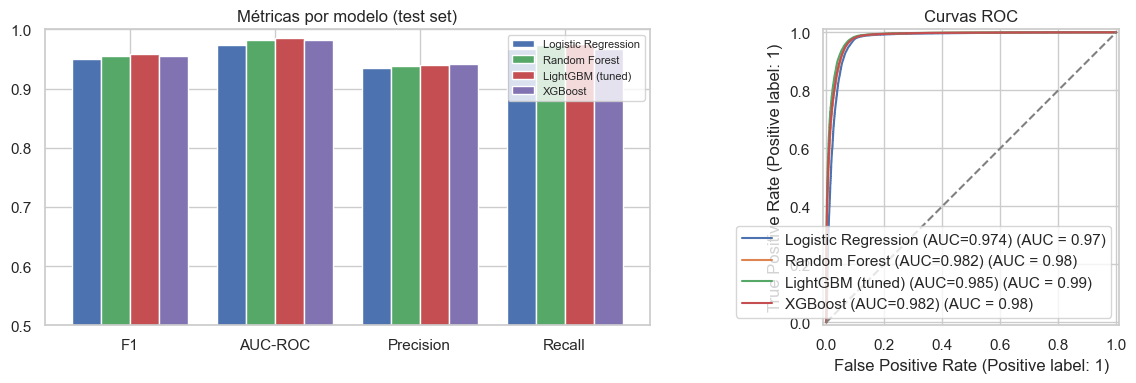

In [22]:
resultados = [res_lr, res_rf, res_lgbm, res_xgb]

comparativa = pd.DataFrame([
    {'Modelo': r['nombre'], 'F1': r['f1'], 'AUC-ROC': r['auc'],
     'Precision': r['precision'], 'Recall': r['recall']}
    for r in resultados
]).sort_values('F1', ascending=False).reset_index(drop=True)

print('Comparativa de modelos (test set):')
print(comparativa.to_string(index=False, float_format='{:.4f}'.format))

# Gráfica comparativa
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

metricas = ['F1', 'AUC-ROC', 'Precision', 'Recall']
x = np.arange(len(metricas))
width = 0.2
colores = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

for i, r in enumerate(resultados):
    vals = [r['f1'], r['auc'], r['precision'], r['recall']]
    axes[0].bar(x + i*width, vals, width, label=r['nombre'], color=colores[i])

axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(metricas)
axes[0].set_ylim(0.5, 1.0)
axes[0].legend(fontsize=8)
axes[0].set_title('Métricas por modelo (test set)')

# Curvas ROC
for r in resultados:
    RocCurveDisplay.from_predictions(
        y_test, r['y_prob'],
        name=f"{r['nombre']} (AUC={r['auc']:.3f})",
        ax=axes[1]
    )
axes[1].plot([0,1],[0,1],'--', color='gray')
axes[1].set_title('Curvas ROC')

plt.tight_layout()
plt.savefig(OUT_DIR / 'model_comparativa.png', bbox_inches='tight', dpi=120)
plt.show()

---
### Selección del modelo campeón

El campeón se selecciona por mayor F1-Score en el test set.

Modelo campeón: LightGBM (tuned)
  F1-Score:  0.9576
  AUC-ROC:   0.9853
  Precision: 0.9399
  Recall:    0.9760


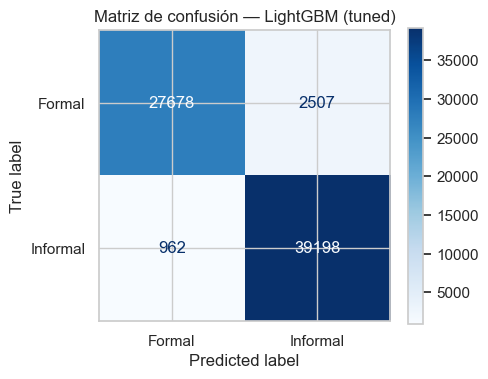

In [23]:
campeon = max(resultados, key=lambda r: r['f1'])
print(f'Modelo campeón: {campeon["nombre"]}')
print(f'  F1-Score:  {campeon["f1"]:.4f}')
print(f'  AUC-ROC:   {campeon["auc"]:.4f}')
print(f'  Precision: {campeon["precision"]:.4f}')
print(f'  Recall:    {campeon["recall"]:.4f}')

# Matriz de confusión del campeón
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, campeon['y_pred'],
    display_labels=['Formal', 'Informal'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de confusión — {campeon["nombre"]}')
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

---
### Análisis SHAP — Interpretabilidad

SHAP (SHapley Additive exPlanations) cuantifica la contribución de cada feature a cada predicción.  
Usamos una muestra de 3000 observaciones del test para eficiencia.

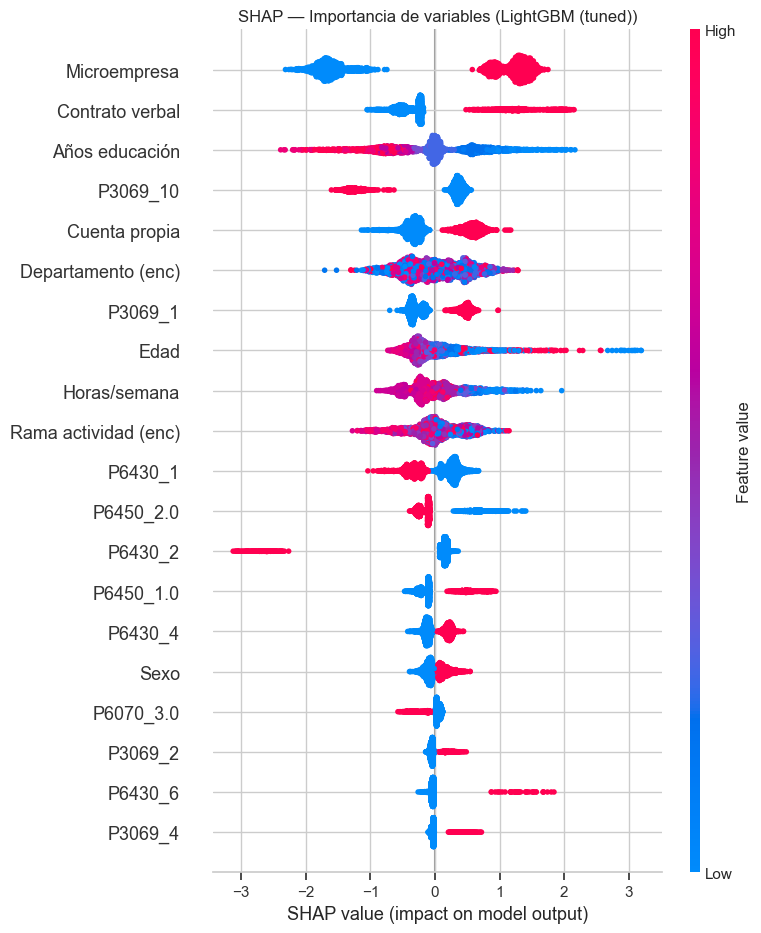

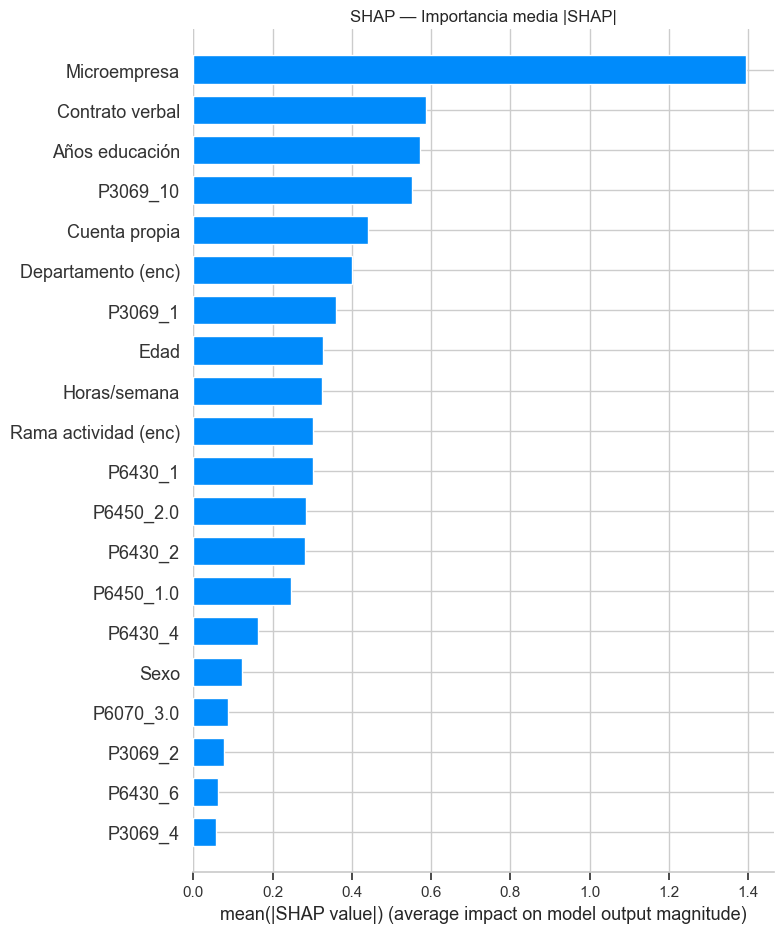

In [24]:
SAMPLE_SHAP = 3000
X_shap = X_test.sample(SAMPLE_SHAP, random_state=42)

explainer   = shap.TreeExplainer(campeon['modelo'])
shap_values = explainer.shap_values(X_shap)

# Para modelos binarios el TreeExplainer devuelve lista [clase0, clase1]
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Nombres legibles para las features
NOMBRES = {
    'P6040': 'Edad', 'ANIOS_EDU': 'Años educación', 'P6800': 'Horas/semana',
    'P3271': 'Sexo', 'CLASE': 'Zona (urbana/rural)',
    'CUENTA_PROPIA': 'Cuenta propia', 'MICROEMPRESA': 'Microempresa',
    'SUBEMPLEADO': 'Subempleado', 'PLURIEMPLEO': 'Pluriempleo',
    'CONTRATO_VERBAL': 'Contrato verbal',
    '0': 'Rama actividad (enc)', '1': 'Departamento (enc)',
}
feat_names = [NOMBRES.get(c, c) for c in X_shap.columns]

# Summary plot (beeswarm)
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X_shap, feature_names=feat_names, show=False, max_display=20)
plt.title(f'SHAP — Importancia de variables ({campeon["nombre"]})')
plt.tight_layout()
plt.savefig(OUT_DIR / 'shap_summary.png', bbox_inches='tight', dpi=120)
plt.show()

# Bar plot (importancia media absoluta)
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X_shap, feature_names=feat_names,
                  plot_type='bar', show=False, max_display=20)
plt.title('SHAP — Importancia media |SHAP|')
plt.tight_layout()
plt.savefig(OUT_DIR / 'shap_importance.png', bbox_inches='tight', dpi=120)
plt.show()

---
### Guardado de artefactos

Genera los archivos que consume `app.py` (Fase 5):  
- `outputs/champion_geih.pkl` — modelo campeón entrenado  
- `outputs/champion_geih_meta.json` — métricas y metadatos  
- `outputs/datos_procesados.parquet` — dataset completo para el EDA del dashboard  
- `outputs/metrics_comparison.csv` — comparativa de todos los modelos

In [25]:
campeon_thresh = campeon.get('threshold', 0.5)

with open(OUT_DIR / 'champion_geih.pkl', 'wb') as f:
    pickle.dump(campeon['modelo'], f)

meta = {
    'model':          campeon['nombre'],
    'threshold':      round(float(campeon_thresh), 2),
    'test_f1':        round(campeon['f1'],        4),
    'test_auc':       round(campeon['auc'],       4),
    'test_precision': round(campeon['precision'], 4),
    'test_recall':    round(campeon['recall'],    4),
    'n_train':        int(len(X_train)),
    'n_test':         int(len(X_test)),
    'n_features':     int(X_train.shape[1]),
    'feature_names':  list(X_train.columns),
}
with open(OUT_DIR / 'champion_geih_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

df_raw   = pd.read_parquet(PARQUET_DIR / 'geih_2024_crudo.parquet')
df_valid = df_raw[df_raw['INFORMAL'].notna()].copy()
df_valid.to_parquet(OUT_DIR / 'datos_procesados.parquet', index=False)

comparativa.to_csv(OUT_DIR / 'metrics_comparison.csv', index=False)

print('Artefactos guardados en outputs/:')
for f in sorted(OUT_DIR.iterdir()):
    mb = f.stat().st_size / (1024 * 1024)
    print(f'  {f.name:<35} {mb:.2f} MB')

print(f'\nModelo campeón: {campeon["nombre"]}')
print(f'  Umbral:  {campeon_thresh:.2f}')
print(f'  F1:      {campeon["f1"]:.4f}')
print(f'  AUC-ROC: {campeon["auc"]:.4f}')

Artefactos guardados en outputs/:
  champion_geih.pkl                   11.48 MB
  champion_geih_meta.json             0.00 MB
  confusion_matrix.png                0.03 MB
  datos_procesados.parquet            6.09 MB
  metrics_comparison.csv              0.00 MB
  model_comparativa.png               0.07 MB
  shap_importance.png                 0.07 MB
  shap_summary.png                    0.13 MB
  viz_01_target.html                  4.63 MB
  viz_02_dpto.html                    4.63 MB
  viz_03_posicion_zona.html           4.63 MB
  viz_04_edu_edad.html                4.63 MB
  viz_05_roc.html                     4.79 MB
  viz_06_shap.html                    4.63 MB

Modelo campeón: LightGBM (tuned)
  Umbral:  0.41
  F1:      0.9576
  AUC-ROC: 0.9853
